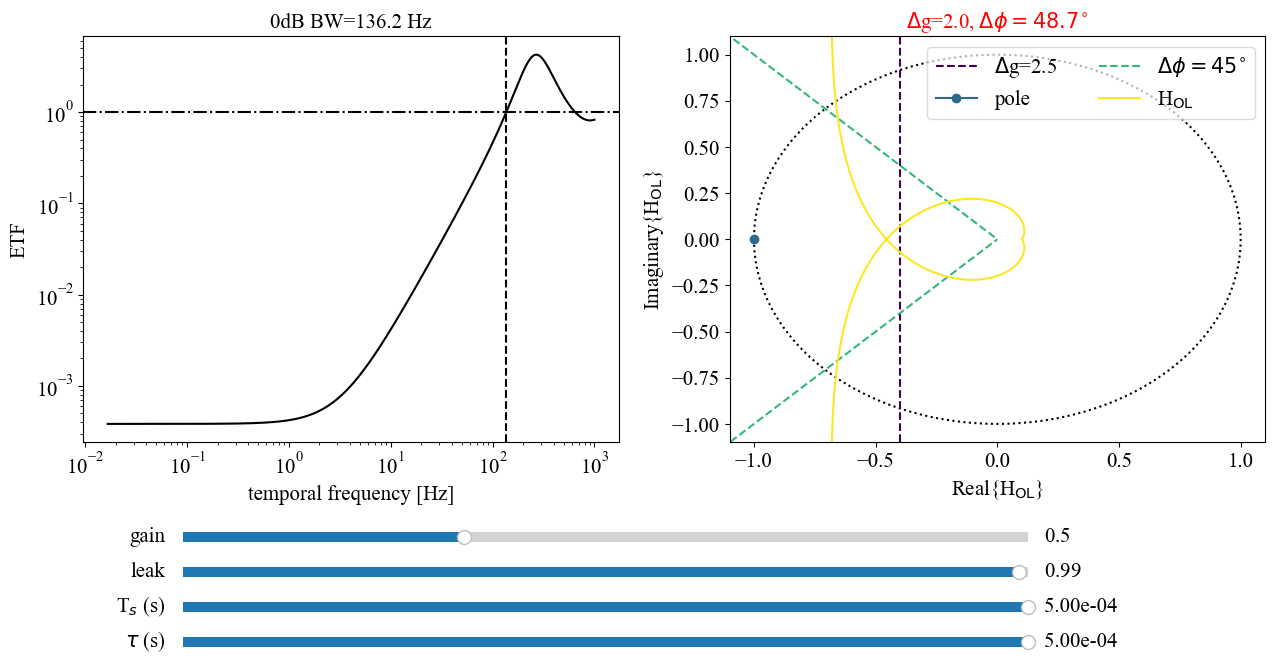

In [2]:
# Copyright 2018 Lawrence Livermore National Security, LLC and other control_gui Project Developers. See the top-level COPYRIGHT file for details.
#
# SPDX-License-Identifier: BSD-3

'''
use this AO contorl GUI to input a gain, leak, frame rate and delay to calculate output bandwidth and gain and phase margin
'''
%matplotlib widget
import numpy as np
import scipy
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.lines import Line2D
from matplotlib import cm
from matplotlib.widgets import Slider, Button, RadioButtons

#AO transfer functions
Hwfs = lambda s, Ts: (1. - np.exp(-Ts*s))/(Ts*s)
Hzoh=Hwfs
Hlag = lambda s,tau: np.exp(-tau*s)
Hint = lambda s, Ts, g: g/(1. - np.exp(-Ts*s)) #integrator
Hlint=  lambda s, Ts, g, l: g/(1. - l*np.exp(-Ts*s)) #leaky integrator
Hcont = Hlint
Holsplane = lambda s, Ts, tau, g, l:  Hwfs(s, Ts)*Hlag(s,tau)*Hcont(s, Ts, g, l)*Hzoh(s,Ts)
s2f = lambda f: 1.j*2.*np.pi*f
Hol = lambda f, Ts, tau, g, l:  Holsplane(s2f(f),Ts,tau,g,l) #open loop transfer function
Hrej = lambda f, Ts, tau, g, l: 1./(1. + Hol(f, Ts, tau, g, l)) #rejection transfer function


Twfs=0.5e-3 #WFS frame rate in s
tau=0.5e-3 #delay in s
gain=0.5
leak=0.99


def gendata(gain,leak,Twfs,tau):
	nframes=1000
	freq=np.logspace(np.log10(1/(60)),np.log10(1/Twfs/2),nframes)
	linfreq=np.linspace(np.min(freq),np.max(freq),nframes)
	def getbw(gain,leak): #get bandwidth
		etf=np.abs(Hrej(freq, Twfs, tau, gain,leak))**2
		indsbw=np.where(np.diff(np.sign(etf-1)))[0] #find the zero crossings, including ones higher than the BW
		bw=np.min(freq[indsbw]) #the BW is the minimum frequency
		return bw
	def genpm(Hol): #phase margin
	        phase_margin_point=np.real(Hol)**2+np.imag(Hol)**2-1 #where the curve hits the Unit Circle. the -1 term allows a sign change to occur when it crosses the unit circle
	        phase_margin_inds=np.where(np.diff(np.sign(phase_margin_point)))[0]
	        if len(phase_margin_inds)==0: #if there are no unit circle crossings, it's definitely not an unstable system! in that case just retun dummy numbers to indicate it is stable
	        	return 0,0,180
	        else:
		        pms=180-np.abs(np.angle(Hol[phase_margin_inds])*180/np.pi)
		        indpms=np.where(pms==np.min(pms)) #use the unit circle crossing corresponding to the minimum phase margin
		        pm,phase_margin_ind=pms[indpms],phase_margin_inds[indpms]
		        pmreal,pmimag=np.real(Hol[phase_margin_ind]),np.imag(Hol[phase_margin_ind])
		        return pmreal,pmimag,pm
	def gengm(Hol): #gain margin
	        zero_crossings = np.where(np.diff(np.sign(np.imag(Hol))))[0]
	        zero_points=np.real(Hol[zero_crossings])
	        return np.min(zero_points)
	def genpmgm(Holp,Holn): #generate phase and gain margins
	        pmrealp,pmimagp,pmp=genpm(Holp)
	        pmrealn,pmimajn,pmn=genpm(Holn)
	        gmp,gmn=gengm(Holp),gengm(Holn)
	        return pmp,pmn,gmp,gmn
	def genNyquist(gain,leak): #generate data for Nyquist diagram
		Holp=Hol(freq, Twfs, tau, gain, leak)
		Holn=Hol(-1*freq, Twfs, tau, gain, leak)
		return Holp,Holn
	def pltNyquist(gain,leak): #plot a Nyquist diagram
		Holp,Holn=genNyquist(gain,leak)
		plt.figure()
		plt.plot(np.real(Holp),np.imag(Holp),color='blue')
		plt.plot(np.real(Holn),np.imag(Holn),color='blue')
		plt.ylabel('Imaginary{Hol}')
		plt.xlabel('Real{Hol}')

	def find_phase_and_gain_margins(gain,leak): #given this frame rate and delay, here's a function to find the phase and gain margins
		Holp,Holn=genNyquist(gain,leak)
		pmp,pmn,gmp,gmn=genpmgm(Holp,Holn)
		pm,gm=np.round(np.min([pmp,pmn]),1),np.round(np.min([gmp,gmn]),1)
		return pm,gm

	etf=np.abs(Hrej(freq, Twfs, tau, gain,leak)**2)
	bw=getbw(gain,leak)
	pmargin,gmargin=find_phase_and_gain_margins(gain,leak)
	Holp,Holn=genNyquist(gain,leak)
	return freq,etf,bw,pmargin,gmargin,Holp,Holn

freq,etf,bw,pmargin,gmargin,Holp,Holn=gendata(gain,leak,Twfs,tau)

size=15
font = {'family' : 'Times New Roman',
        'size'   : size}

mpl.rc('font', **font)
mpl.rcParams['image.interpolation'] = 'nearest'

colors=cm.viridis(np.linspace(0,0.75,3))
fig,axs=plt.subplots(nrows=1,ncols=2,figsize=(13,7))
ax1,ax3=axs.ravel()

ax1.set_yscale('log')
ax1.set_xscale('log')
ax1.set_ylabel('ETF')
ax1.set_xlabel('temporal frequency [Hz]')
ax1.set_title('0dB BW='+str(np.round(bw,1))+' Hz',size=size)
[etf_line]=ax1.plot(freq,np.abs(Hrej(freq, Twfs, tau, gain,leak)**2),color='k')
bw_line=ax1.axvline(bw,color='k',ls='--')
ax1.axhline(1,color='k',ls='-.')


colors=cm.viridis(np.linspace(0,1,4))
phasegrid=np.linspace(-np.pi,np.pi,500)
xunit,yunit=np.cos(phasegrid),np.sin(phasegrid)
ax3.plot(xunit,yunit,color='k',ls=':')
gain_margin_limit=2.5
if pmargin<=45 or -1/gmargin<=2.5:
	pmgmcolor='red'
else:
	pmgmcolor='black'
ax3.set_title('$\\Delta$g='+str(round(-1/gmargin,1))+', $\\Delta\\phi='+str(round(pmargin,1))+'^{\\circ}$',size=size,color=pmgmcolor)
ax3.axvline(-1/gain_margin_limit,color=colors[0],ls='--',label='$\\Delta$g=2.5')

ax3.plot(-1,0,'-o',color=colors[1],label='pole')
ax3.set_xlim(-1.1,1.1)
ax3.set_ylim(-1.1,1.1)
ax3.plot(np.linspace(-2,0,10),np.linspace(-2,0,10),color=colors[2],ls='--',label='$\\Delta\\phi=45^{\\circ}$')
ax3.plot(np.linspace(-2,0,10),np.linspace(2,0,10),color=colors[2],ls='--')

[nyquistp_line]=ax3.plot(np.real(Holp),np.imag(Holp),color=colors[3],label='H$_\\mathrm{OL}$')
[nyquistn_line]=ax3.plot(np.real(Holn),np.imag(Holn),color=colors[3])
ax3.legend(loc='best',framealpha=0.7,ncol=2)
ax3.set_ylabel('Imaginary{H$_\\mathrm{OL}$}')
ax3.set_xlabel('Real{H$_\\mathrm{OL}$}')
plt.tight_layout()

fig.subplots_adjust(bottom=0.35)

gain_ax  = fig.add_axes([0.15, 0.2, 0.65, 0.03])
leak_ax  = fig.add_axes([0.15, 0.15, 0.65, 0.03])
Twfs_ax  = fig.add_axes([0.15, 0.1, 0.65, 0.03])
tau_ax  = fig.add_axes([0.15, 0.05, 0.65, 0.03])


gain_slider = Slider(gain_ax, 'gain',0.0,1.5, valinit=gain 	)
leak_slider = Slider(leak_ax, 'leak',0,1, valinit=leak)
Twfs_slider = Slider(Twfs_ax, 'T$_s$ (s)',0.1e-3,0.5e-3, valinit=Twfs,valfmt='%.2e')
tau_slider = Slider(tau_ax, '$\\tau$ (s)',0.1e-3,0.5e-3, valinit=tau,valfmt='%.2e')


def sliders_on_changed(val):
	gain=gain_slider.val
	leak=leak_slider.val
	Twfs=Twfs_slider.val
	tau=tau_slider.val

	freq,etf,bw,pmargin,gmargin,Holp,Holn=gendata(gain,leak,Twfs,tau)


	ax1.set_title('0db BW='+str(np.round(bw,1))+' Hz',size=size)
	ax1ydata=np.abs(Hrej(freq, Twfs, tau, gain,leak)**2)
	etf_line.set_data(freq,ax1ydata)
	bw_line.set_xdata([bw])
	ax1.set_ylim(np.min(ax1ydata)*0.5,np.max(ax1ydata)*1.5)
	ax1.set_xlim(freq[0]*0.5,freq[-1]*1.5)

	if pmargin<=45 or -1/gmargin<=2.5:
		pmgmcolor='red'
	else:
		pmgmcolor='black'
	ax3.set_title('$\\Delta$g='+str(round(-1/gmargin,1))+', $\\Delta\\phi='+str(round(pmargin,1))+'^{\\circ}$',size=size,color=pmgmcolor)
	nyquistp_line.set_data(np.real(Holp),np.imag(Holp))
	nyquistn_line.set_data(np.real(Holn),np.imag(Holn))

	fig.canvas.draw_idle()

gain_slider.on_changed(sliders_on_changed)
leak_slider.on_changed(sliders_on_changed)
Twfs_slider.on_changed(sliders_on_changed)
tau_slider.on_changed(sliders_on_changed)


plt.show()